### Name: Rohiya Shafiq
### Registration No. : 25-28-0053

### Part A

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
train_data = pd.read_csv("D:/Semester_2/Deep Learning/Assignments/train.csv")
test_data = pd.read_csv("D:/Semester_2/Deep Learning/Assignments/test.csv")

n_samples = train_data.shape[0]
n_features = train_data.shape[1]

print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")
print(train_data.dtypes)

Number of samples: 41348
Number of features: 7
neighbourhood_group        str
room_type                  str
minimum_nights         float64
amenity_score          float64
number_of_reviews      float64
availability_365       float64
price_class              int64
dtype: object


In [3]:
any_missing = train_data.isnull().sum()
print(any_missing)


neighbourhood_group     839
room_type               611
minimum_nights         1322
amenity_score           916
number_of_reviews      1123
availability_365        595
price_class               0
dtype: int64


In [4]:
mode_neighour = train_data['neighbourhood_group'].mode()[0]
mode_roomtype = train_data['room_type'].mode()[0]
median_mininights = train_data['minimum_nights'].median()
median_amenity = train_data['amenity_score'].median()
median_reviews = train_data['number_of_reviews'].median()
median_availability = train_data['availability_365'].median()

# Fill missing values
train_data['neighbourhood_group'] = train_data['neighbourhood_group'].fillna(mode_neighour)
train_data['room_type'] = train_data['room_type'].fillna(mode_roomtype)
train_data['minimum_nights'] = train_data['minimum_nights'].fillna(median_mininights)
train_data['amenity_score'] = train_data['amenity_score'].fillna(median_amenity)
train_data['number_of_reviews'] = train_data['number_of_reviews'].fillna(median_reviews)
train_data['availability_365'] = train_data['availability_365'].fillna(median_availability)


missing = train_data.isnull().sum()
print(missing)

neighbourhood_group    0
room_type              0
minimum_nights         0
amenity_score          0
number_of_reviews      0
availability_365       0
price_class            0
dtype: int64


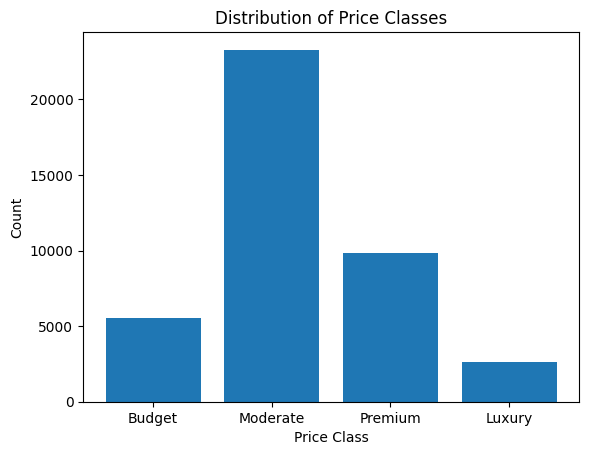

In [5]:
train_data['price_class'].value_counts()
train_data['price_class'].value_counts(normalize=True) * 100


counts = train_data['price_class'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xticks(
    ticks=[0,1,2,3],
    labels=["Budget", "Moderate", "Premium", "Luxury"]
)
plt.xlabel("Price Class")
plt.ylabel("Count")
plt.title("Distribution of Price Classes")
plt.show()

In [6]:
categorical_cols = ['neighbourhood_group', 'room_type']
train_data['neighbourhood_group'] = train_data['neighbourhood_group'].astype('category')
train_data['room_type'] = train_data['room_type'].astype('category')

train_data_encoded = pd.get_dummies(
    train_data,
    columns=categorical_cols,
    drop_first=True
)
print(train_data_encoded.select_dtypes(include=['object', 'string']))


Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[41348 rows x 0 columns]


In [7]:
cols_normalize = ['minimum_nights', 'number_of_reviews', 'availability_365', 'amenity_score']

scaler = StandardScaler()
train_data_encoded[cols_normalize] = scaler.fit_transform(train_data_encoded[cols_normalize])
train_data_encoded[cols_normalize].head()

,minimum_nights,number_of_reviews,availability_365,amenity_score
0,-0.251024,-0.184981,1.095654,1.586358
1,-0.251024,-0.503065,-0.849587,0.089685
2,-0.251024,1.064634,-0.160329,-0.216925
3,-0.251024,-0.503065,-0.512616,0.354721
4,-0.251024,-0.525785,-0.167987,-1.027623


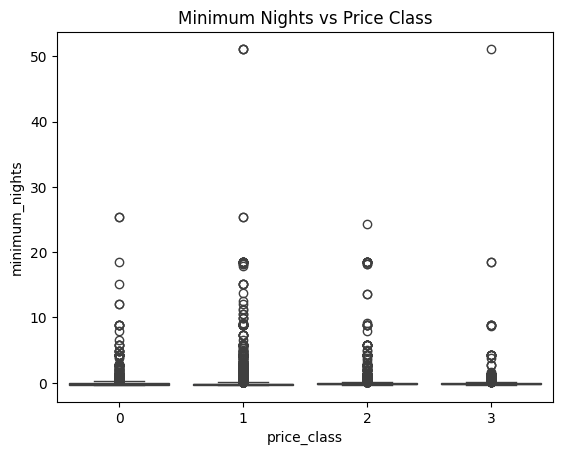

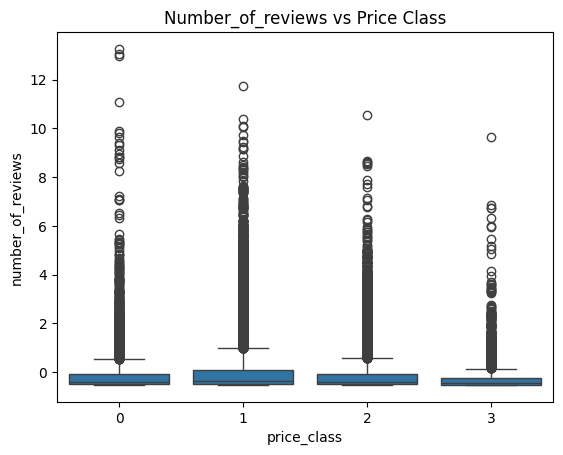

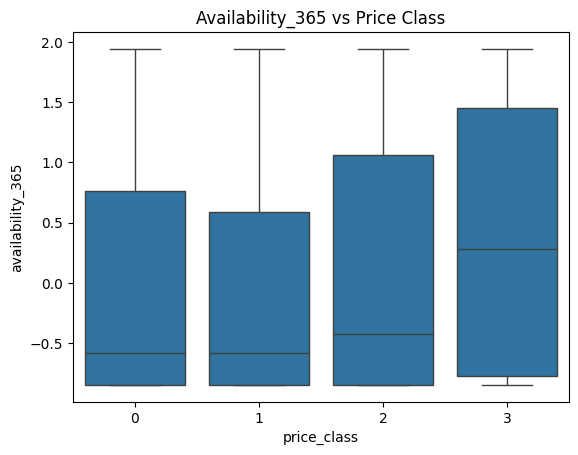

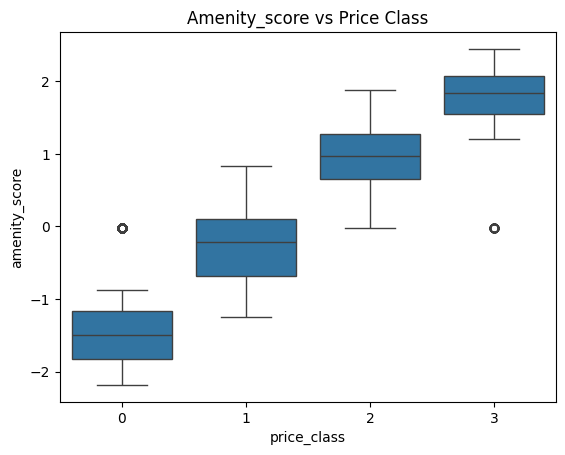

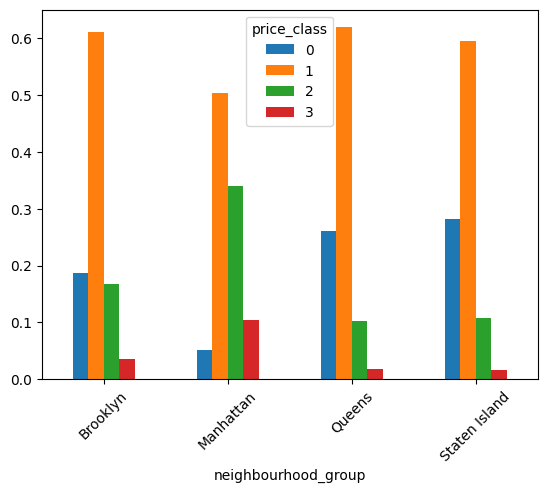

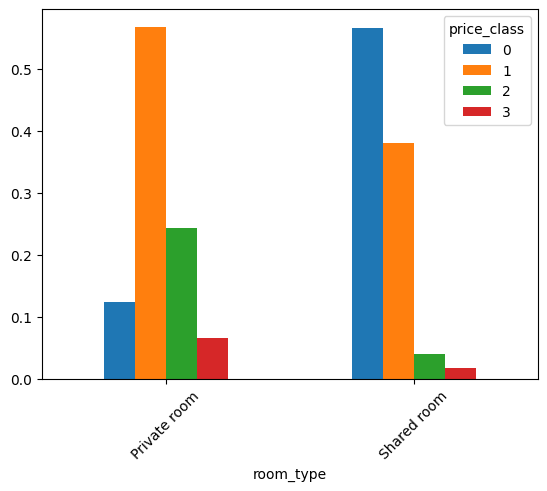

In [8]:
cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]
title_names = ["Minimum Nights vs Price Class", "Number_of_reviews vs Price Class", "Availability_365 vs Price Class", "Amenity_score vs Price Class"]
for i in range(0, len(cols)):
    sns.boxplot(x='price_class', y= cols[i], data=train_data_encoded)
    plt.title(title_names[i])
    plt.show()

neigh_cols = [col for col in train_data_encoded.columns 
              if col.startswith("neighbourhood_group_")]

train_data_encoded['neighbourhood_group'] = (
    train_data_encoded[neigh_cols]
    .idxmax(axis=1)
    .str.replace("neighbourhood_group_", "")
)

pd.crosstab(train_data_encoded['neighbourhood_group'], train_data_encoded['price_class'], normalize='index').plot(kind='bar')

plt.xticks(rotation=45)
plt.show()

room_cols = [col for col in train_data_encoded.columns 
              if col.startswith("room_type_")]

train_data_encoded['room_type'] = (
    train_data_encoded[room_cols]
    .idxmax(axis=1)
    .str.replace("room_type_", "")
)

pd.crosstab(train_data_encoded['room_type'], train_data_encoded['price_class'], normalize='index').plot(kind='bar')

plt.xticks(rotation=45)
plt.show()

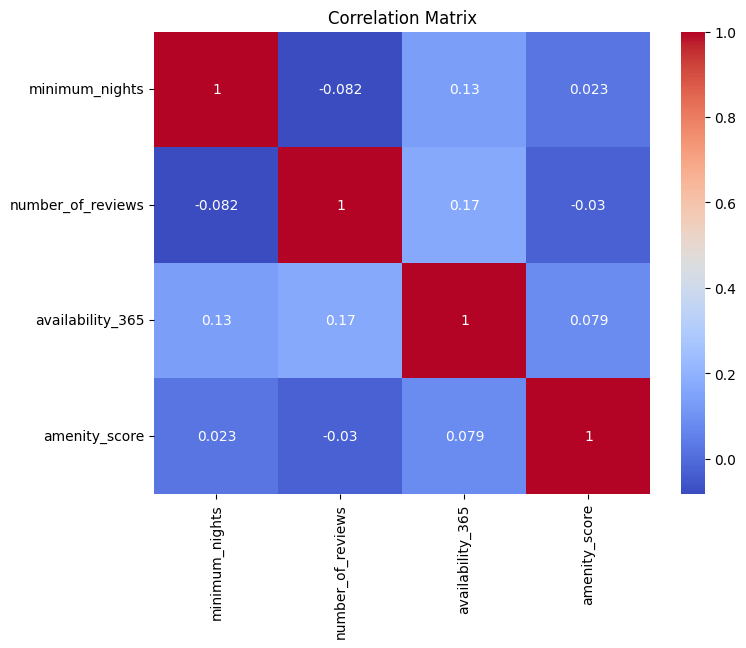

In [9]:
num_cols = ["minimum_nights", "number_of_reviews", "availability_365", "amenity_score"]
corr_matrix = train_data_encoded[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Part B

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / m

In [12]:
class TwoLayerNN:
    
    def __init__(self, input_dim, h1, h2, output_dim, activation='sigmoid'):
        
        self.activation = activation
        
        # Initialize weights
        self.W1 = np.random.randn(input_dim, h1) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, h1))
        
        self.W2 = np.random.randn(h1, h2) * np.sqrt(2 / h1)
        self.b2 = np.zeros((1, h2))
        
        self.W3 = np.random.randn(h2, output_dim) * np.sqrt(2 / h1)
        self.b3 = np.zeros((1, output_dim))
        

    # Forward Pass
    def forward(self, X):
        # hidden layer 1
        self.Z1 = X @ self.W1 + self.b1
        if self.activation == 'sigmoid':
            self.A1 = sigmoid(self.Z1)
        else:
            self.A1 = relu(self.Z1)
        
        # hidden layer 2
        self.Z2 = self.A1 @ self.W2 + self.b2
        if self.activation == 'sigmoid':
            self.A2 = sigmoid(self.Z2)
        else:
            self.A2 = relu(self.Z2)
        
        # Output layer
        self.Z3 = self.A2 @ self.W3 + self.b3
        self.A3 = softmax(self.Z3)
        
        return self.A3
    

    # Backward Pass
    def backward(self, X, y, lr):
        
        m = X.shape[0]
        
        # Output layer gradient
        dZ3 = self.A3 - y
        dW3 = (self.A2.T @ dZ3) / m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / m
        
        # Hidden layer 2
        dA2 = dZ3 @ self.W3.T
        
        if self.activation == 'sigmoid':
            dZ2 = dA2 * sigmoid_derivative(self.A2)
        else:
            dZ2 = dA2 * relu_derivative(self.Z2)
            
        dW2 = (self.A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        # Hidden layer 1
        dA1 = dZ2 @ self.W2.T
        
        if self.activation == 'sigmoid':
            dZ1 = dA1 * sigmoid_derivative(self.A1)
        else:
            dZ1 = dA1 * relu_derivative(self.Z1)
            
        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        mean_W1 = np.mean(np.abs(dW1))
        mean_W2 = np.mean(np.abs(dW2))
        
        # Update
        self.W3 = self.W3 - lr * dW3
        self.b3 = self.b3 - lr * db3
        
        self.W2 = self.W2 - lr * dW2
        self.b2 = self.b2 - lr * db2
        
        self.W1 = self.W1 -  lr * dW1
        self.b1 = self.b1 - lr * db1

        return mean_W1, mean_W2

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)
    

    # Training
    def train(self, X_train, y_train, X_val, y_val, lr=0.1, iterations=200):
        train_acc_list = []
        val_acc_list = []

        grad_W1 = []
        grad_W2 = []

        for i in range(iterations):
            
            y_pred = self.forward(X_train)
            loss = cross_entropy(y_train, y_pred)
            
            mean1 , mean2 = self.backward(X_train, y_train, lr)
            grad_W1.append(mean1)
            grad_W2.append(mean2)

            train_pred = self.predict(X_train)
            val_pred = self.predict(X_val)
            train_acc = np.mean(train_pred == np.argmax(y_train, axis=1))
            val_acc = np.mean(val_pred == np.argmax(y_val, axis=1))
            
            train_acc_list.append(train_acc)
            val_acc_list.append(val_acc)
            
            if i % 20 == 0:
                print(f"Iteration {i}, Loss: {loss:.4f}")

        return train_acc_list, val_acc_list, grad_W1, grad_W2

In [13]:
y = train_data_encoded['price_class'].to_numpy(dtype=int)

# Separate features
X_raw = train_data_encoded.drop('price_class', axis=1)

# One-hot encode categorical features
X_encoded = pd.get_dummies(X_raw, drop_first=True)

X_encoded = X_encoded.loc[:, ~X_encoded.columns.duplicated()]

# Convert to float numpy array
X = X_encoded.to_numpy(dtype=float)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)


num_classes = 4

y_train_onehot = np.zeros((y_train.shape[0], num_classes))
y_train_onehot[np.arange(y_train.shape[0]), y_train] = 1

y_val_onehot = np.zeros((y_val.shape[0], num_classes))
y_val_onehot[np.arange(y_val.shape[0]), y_val] = 1

input_dim = X_train.shape[1]

# Sigmoid Network
model_sigmoid = TwoLayerNN(input_dim=input_dim, h1=16, h2=16, output_dim=4, activation='sigmoid')
sigmoid_train_acc, sigmoid_valid_acc, grad1_sig, grad2_sig = model_sigmoid.train(X_train, y_train_onehot, X_val, y_val_onehot, lr=0.01, iterations=200)

# ReLU Network
model_relu = TwoLayerNN(input_dim=input_dim, h1=16, h2=16, output_dim=4, activation='relu')
relu_train_acc, relu_valid_acc, grad1_relu, grad2_relu = model_relu.train(X_train, y_train_onehot, X_val, y_val_onehot, lr=0.1, iterations=200)

Iteration 0, Loss: 1.5493
Iteration 20, Loss: 1.3081
Iteration 40, Loss: 1.1925
Iteration 60, Loss: 1.1417
Iteration 80, Loss: 1.1189
Iteration 100, Loss: 1.1075
Iteration 120, Loss: 1.1009
Iteration 140, Loss: 1.0965
Iteration 160, Loss: 1.0931
Iteration 180, Loss: 1.0903
Iteration 0, Loss: 2.7582
Iteration 20, Loss: 0.8181
Iteration 40, Loss: 0.6114
Iteration 60, Loss: 0.5178
Iteration 80, Loss: 0.4714
Iteration 100, Loss: 0.4457
Iteration 120, Loss: 0.4299
Iteration 140, Loss: 0.4192
Iteration 160, Loss: 0.4114
Iteration 180, Loss: 0.4054


In [14]:
print("Final Accuracies:")
print(f"Sigmoid: Train Acc = {sigmoid_train_acc[-1]:.3f}, Val Acc = {sigmoid_valid_acc[-1]:.3f}")
print(f"ReLU:    Train Acc = {relu_train_acc[-1]:.3f}, Val Acc = {relu_valid_acc[-1]:.3f}")

Final Accuracies:
Sigmoid: Train Acc = 0.564, Val Acc = 0.558
ReLU:    Train Acc = 0.827, Val Acc = 0.820


200


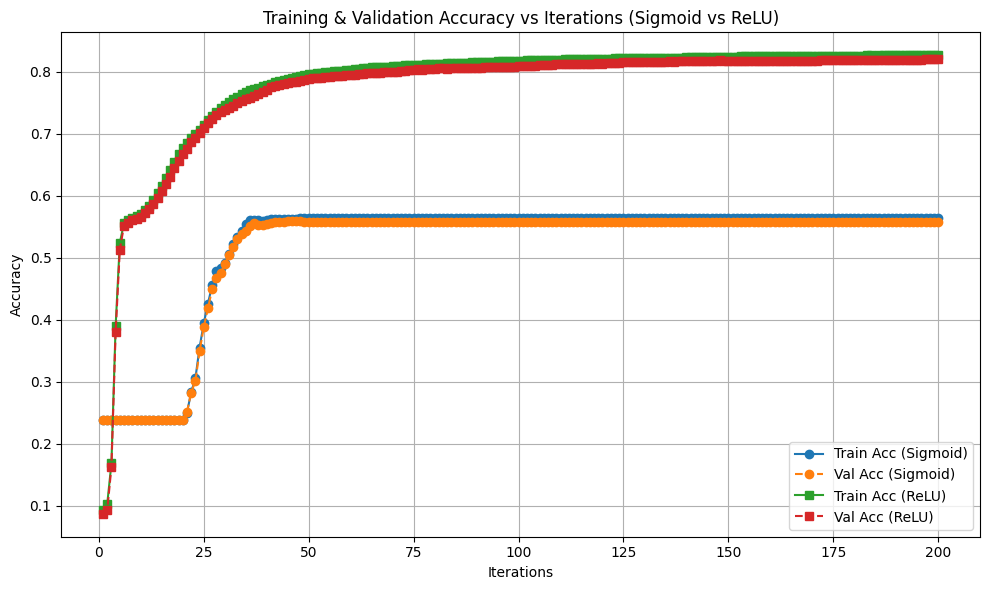

In [15]:
iterations = range(1, len(sigmoid_train_acc)+1)
print(len(iterations))

plt.figure(figsize=(10,6))

# Sigmoid curves
plt.plot(iterations, sigmoid_train_acc, marker='o', linestyle='-', label="Train Acc (Sigmoid)")
plt.plot(iterations, sigmoid_valid_acc, marker='o', linestyle='--', label="Val Acc (Sigmoid)")

# ReLU curves
plt.plot(iterations, relu_train_acc, marker='s', linestyle='-', label="Train Acc (ReLU)")
plt.plot(iterations, relu_valid_acc, marker='s', linestyle='--', label="Val Acc (ReLU)")

plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy vs Iterations (Sigmoid vs ReLU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

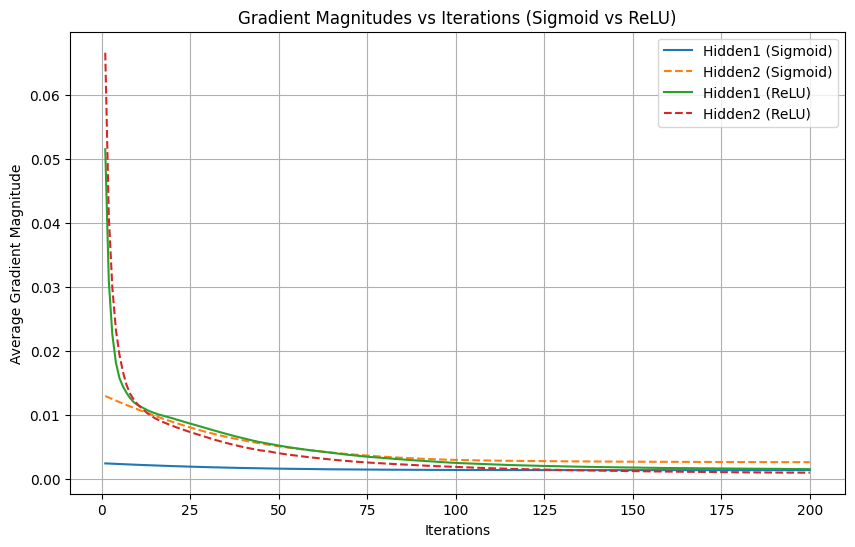

In [16]:
iterations = range(1, 201)

plt.figure(figsize=(10,6))

# Sigmoid
plt.plot(iterations, grad1_sig, label="Hidden1 (Sigmoid)")
plt.plot(iterations, grad2_sig, linestyle='--', label="Hidden2 (Sigmoid)")

# ReLU
plt.plot(iterations, grad1_relu, label="Hidden1 (ReLU)")
plt.plot(iterations, grad2_relu, linestyle='--', label="Hidden2 (ReLU)")

plt.xlabel("Iterations")
plt.ylabel("Average Gradient Magnitude")
plt.title("Gradient Magnitudes vs Iterations (Sigmoid vs ReLU)")
plt.legend()
plt.grid(True)
plt.show()

### Part C


In [17]:
def compute_input_sensitivity(model, x):
    """
    Computes |∂o_m / ∂x| for a single instance x
    """
    
    x = x.reshape(1, -1)

    # Forward pass
    output = model.forward(x)
    winning_class = np.argmax(output)

    # One-hot vector for winning class
    dZ3 = np.zeros_like(output)
    dZ3[0, winning_class] = 1

    # Backprop from output to input

    # Through W3
    dA2 = dZ3 @ model.W3.T

    if model.activation == 'sigmoid':
        dZ2 = dA2 * sigmoid_derivative(model.A2)
    else:
        dZ2 = dA2 * relu_derivative(model.Z2)

    # Through W2
    dA1 = dZ2 @ model.W2.T

    if model.activation == 'sigmoid':
        dZ1 = dA1 * sigmoid_derivative(model.A1)
    else:
        dZ1 = dA1 * relu_derivative(model.Z1)

    # Through W1 to input
    dX = dZ1 @ model.W1.T

    sensitivity = np.abs(dX).flatten()

    return sensitivity, winning_class


In [18]:

feature_names = train_data_encoded.drop("price_class", axis=1).columns.tolist()
sensitivity, winning_class = compute_input_sensitivity(model_relu, X_val[0])

feature_ranking = sorted(
    zip(feature_names, sensitivity),
    key=lambda x: x[1],
    reverse=True
)

print("Top 10 Influential Features:")
for f, score in feature_ranking[:10]:
    print(f"{f}: {score:.6f}")

Top 10 Influential Features:
amenity_score: 3.109038
room_type_Private room: 1.573241
neighbourhood_group_Manhattan: 1.325669
neighbourhood_group_Staten Island: 1.289462
neighbourhood_group_Brooklyn: 1.194158
neighbourhood_group_Queens: 0.532993
minimum_nights: 0.382220
availability_365: 0.350405
number_of_reviews: 0.345466
room_type_Shared room: 0.198085


### Part D

In [25]:
y_test = test_data['price_class'].to_numpy(dtype=int)
X_test_raw = test_data.drop('price_class', axis=1)
cols_normalize = ['minimum_nights', 'number_of_reviews', 'availability_365', 'amenity_score']

# 2. Get dummies and clean duplicates from test
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=True)
X_test_encoded = X_test_encoded.loc[:, ~X_test_encoded.columns.duplicated()]

# 3. THE "GOLDEN ALIGNMENT" STEP
# This forces the test set to have the EXACT same columns as X_encoded (training)
X_test_final = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

X_test_final = X_test_final.astype(float)

X_test_final[cols_normalize] = scaler.transform(X_test_final[cols_normalize])

# 6. Sigmoid model evaluation
sigmoid_test_preds = model_sigmoid.predict(X_test_final.to_numpy())
# argmax converts probabilities [0.1, 0.7, 0.2] -> class 1
sigmoid_test_labels = sigmoid_test_preds
sigmoid_test_acc = np.mean(sigmoid_test_labels == y_test)
print(f"Sigmoid Test Accuracy: {sigmoid_test_acc:.4f}")

# 7. ReLU model evaluation
relu_test_preds = model_relu.predict(X_test_final.to_numpy())
relu_test_labels = relu_test_preds
relu_test_acc = np.mean(relu_test_labels == y_test)
print(f"ReLU Test Accuracy: {relu_test_acc:.4f}")

Sigmoid Test Accuracy: 0.5631
ReLU Test Accuracy: 0.3523


In [27]:
print("FINAL PERFORMANCE COMPARISON")

print(f"Sigmoid -> "
      f"Train: {sigmoid_train_acc[-1]:.4f}, "
      f"Val: {sigmoid_valid_acc[-1]:.4f}, "
      f"Test: {sigmoid_test_acc:.4f}")

print(f"ReLU    -> "
      f"Train: {relu_train_acc[-1]:.4f}, "
      f"Val: {relu_valid_acc[-1]:.4f}, "
      f"Test: {relu_test_acc:.4f}")


print("\nGeneralization Gap (Train - Test)")
print(f"Sigmoid Gap: {sigmoid_train_acc[-1] - sigmoid_test_acc:.4f}")
print(f"ReLU Gap:    {relu_train_acc[-1] - relu_test_acc:.4f}")

FINAL PERFORMANCE COMPARISON
Sigmoid -> Train: 0.5644, Val: 0.5583, Test: 0.5631
ReLU    -> Train: 0.8270, Val: 0.8204, Test: 0.3523

Generalization Gap (Train - Test)
Sigmoid Gap: 0.0013
ReLU Gap:    0.4746
